# Bài 1: Biểu diễn dữ liệu thành ma trận & độ tương đồng

# 1. Biến dữ liệu thành ma trận

In [ ]:
import numpy as np
from PIL import Image

M = np.array(Image.open("anh.jpg").convert("L"), dtype=float)
print(M.shape)
h, w = M.shape
patch_size = 200
max_h = (h // patch_size) * patch_size
max_w = (w // patch_size) * patch_size

newimage = []
patch_size = 200
for i in range(0, max_h, patch_size):
    for j in range(0, max_w, patch_size):
        patch = M[i : i + patch_size, j : j + patch_size]
        vector_1d = patch.flatten()
        newimage.append(vector_1d)
X = np.array(newimage)
print("Kích thước ma trận X:", X.shape)

(675, 1200)
Kích thước ma trận X: (18, 40000)




*  Ma trận X có kích thước (9, 40000).
*   Mỗi hàng: Đại diện cho một bức ảnh con (patch) đã được duỗi thẳng thành một vector.

*   Mỗi cột: Đại diện cho giá trị điểm ảnh (pixel) tại một vị trí tương ứng trên tất cả các bức ảnh con đó.

# 2.Phép toán cơ bản

In [ ]:
X_mean = np.mean(X, axis = 0)
print("shape X lúc đầu", X.shape)
print("shape vector trung bình", X_mean.shape)
print("shape X lúc sau", (X - X_mean).shape)

shape X lúc đầu (18, 40000)
shape vector trung bình (40000,)
shape X lúc sau (18, 40000)




*   Lúc đầu X có kích thước (9, 40000) (2 chiều) còn kích thước của X_mean là (40000,) (1 chiều)
*   Theo lý thuyết thì 2 ma trận khác kích thước thì không thể trừ cho nhau. Nhưng do cơ chế Broadcasting mà X_mean đã tự động thành 9 hàng và có kích thước (9, 40000). Vì vậy kích thước lúc sau vẫn được giữ nguyễn là (9, 40000)



# 3.Ma trận tương đồng

In [ ]:
def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis = 1, keepdims= True)
    Yn = Y / np.linalg.norm(Y, axis = 1, keepdims= True)
    return Xn @ Yn.T

# 4.Truy vấn

In [ ]:
def search(query, top_k = 3):
    sims = cosine_similarity(query, X).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    diem = sims[idx]
    return idx, diem
query = X[0:1]
idx, diem = search(query, top_k=3)
print("Top 3 ảnh giống nhau nhất", idx)
print("Điểm cosine tương ứng", np.round(diem, 4))

Top 3 ảnh giống nhau nhất [0 5 1]
Điểm cosine tương ứng [1.     0.9708 0.9585]


Test với ảnh 0

#5. Nhận xét

In [ ]:
S = cosine_similarity(X)
S_copy_max = S.copy()
np.fill_diagonal(S_copy_max, -np.inf)
max_idx = np.unravel_index(np.argmax(S_copy_max), S_copy_max.shape)

S_copy_min = S.copy()
np.fill_diagonal(S_copy_min, np.inf)
min_idx = np.unravel_index(np.argmin(S_copy_min), S_copy_min.shape)

print(f"Cặp giống nhau nhất là ảnh {max_idx[0]} và ảnh {max_idx[1]} với điểm Cosine: {S[max_idx]:.4f}")
print(f"Cặp khác nhau nhất là ảnh {min_idx[0]} và ảnh {min_idx[1]} với điểm Cosine: {S[min_idx]:.4f}")

Cặp giống nhau nhất là ảnh 1 và ảnh 5 với điểm Cosine: 0.9794
Cặp khác nhau nhất là ảnh 6 và ảnh 12 với điểm Cosine: 0.8201


Kết quả hoàn toàn khớp với trực giác

# Bài 2: Biến đổi tuyến tính & SVD

# Biến đổi tuyến tính

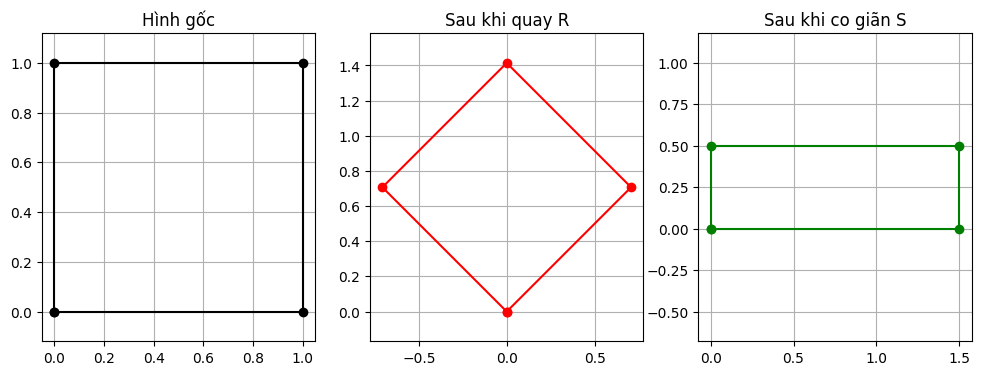

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

Sa = np.array([[1.5, 0],
                  [0, 0.5]])

hinha = R @ square
hinhb = Sa @ square

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(square[0], square[1], marker='o', color='black')
plt.title("Hình gốc")
plt.axis('equal');
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(hinha[0], hinha[1], marker='o', color='red')
plt.title("Sau khi quay R")
plt.axis('equal');
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(hinhb[0], hinhb[1], marker='o', color='green')
plt.title("Sau khi co giãn S")
plt.axis('equal');
plt.grid()
plt.show()


# Nén ảnh bằng SVD và đánh giá

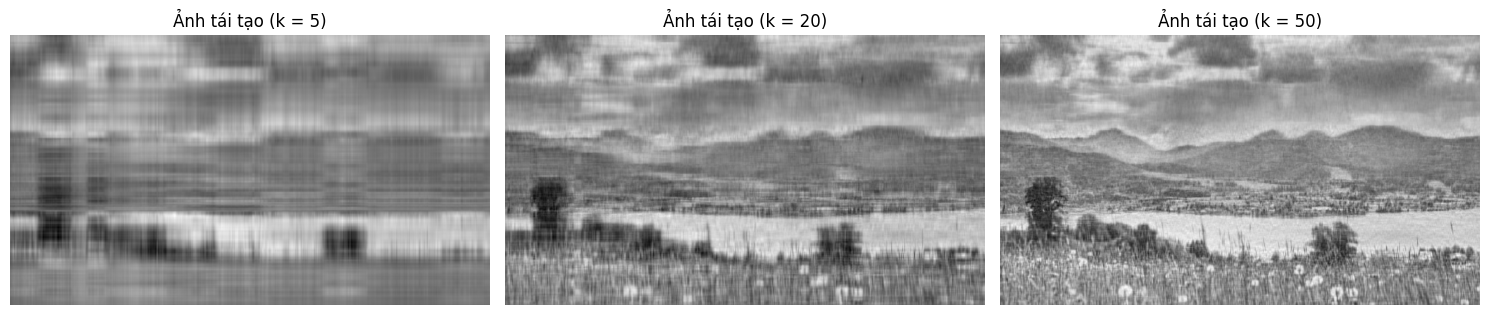

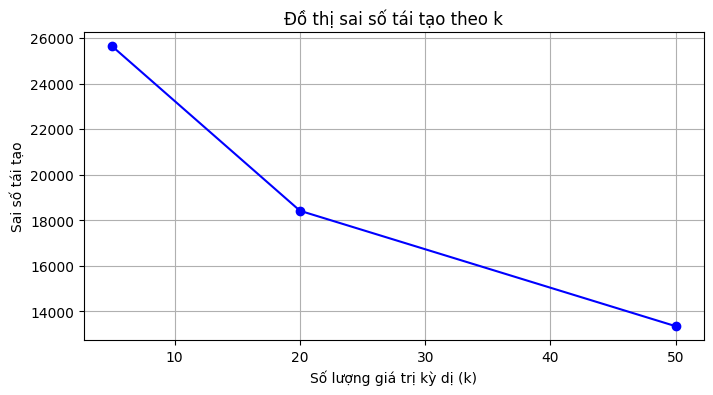

Bảng đánh giá
k =  5 | Tỉ lệ nén: 86.35 lần | Sai số: 25651.18
k = 20 | Tỉ lệ nén: 21.59 lần | Sai số: 18421.59
k = 50 | Tỉ lệ nén: 8.64 lần | Sai số: 13349.48


In [ ]:
M = np.array(Image.open("anh.jpg").convert("L"), dtype=float)
U, S, Vt = np.linalg.svd(M, full_matrices= False)

def reconstruct(k):
    return (U[:, :k] * S[:k] @ Vt[:k, :])

k_values = [5, 20, 50]
saiso = []
tile = []
h, w = M.shape
kichthuocgoc = h * w
plt.figure(figsize=(15, 5))

for i, k in enumerate(k_values):
    M_k = reconstruct(k)

    plt.subplot(1, len(k_values), i + 1)
    plt.imshow(M_k, cmap='gray')
    plt.title(f"Ảnh tái tạo (k = {k})")
    plt.axis('off')

    a = np.linalg.norm(M - M_k)
    saiso.append(a)

    kichthuocnen = k * (h + w + 1)
    b = kichthuocgoc / kichthuocnen
    tile.append(b)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(k_values, saiso, marker='o', linestyle='-', color='b')
plt.title("Đồ thị sai số tái tạo theo k")
plt.xlabel("Số lượng giá trị kỳ dị (k)")
plt.ylabel("Sai số tái tạo")
plt.grid()
plt.show()

print("Bảng đánh giá")
for i, k in enumerate(k_values):
    print(f"k = {k:2d} | Tỉ lệ nén: {tile[i]:.2f} lần | Sai số: {saiso[i]:.2f}")

# Nhận xét:
# Về ngưỡng k chấp nhận được:

*   Qua bài, ảnh tái tạo ở mức k = 50 là ta có thể chấp nhận được.
*   Ở mức k này, tuy chỉ sử dụng một lượng rất nhỏ dữ liệu gốc nhưng năng lượng tích lũy đã đạt trên 90%, đủ để giữ lại toàn bộ hình khối, ánh sáng và các đường nét chính của ảnh, chỉ bỏ qua các chi tiết vi mô.


# Liên hệ với nén dữ liệu và giảm chiều trong AI:


*   Việc vứt bỏ các giá trị kỳ dị nhỏ ở đuôi mảng S chính là quá trình lọc nhiễu và trích xuất đặc trưng chính.

*   Tương tự như nguyên lý PCA trong AI, SVD giúp nén một vector dữ liệu khổng lồ thành một không gian k chiều nhỏ gọn hơn nhiều.


*   Hiệu quả thực tế: Giúp mô hình Machine Learning loại bỏ các dữ liệu rác, tránh hiện tượng overfitting, tiết kiệm bộ nhớ lưu trữ và tăng tốc độ tính toán ma trận lên nhiều lần.







# **Bonus**

Tổng số giá trị kỳ dị tối đa: 675
Giá trị k tối thiểu cần chọn để giữ lại >= 90% thông tin là: k = 1
Năng lượng tích lũy tại k = 1: 0.9338 (93.38%)


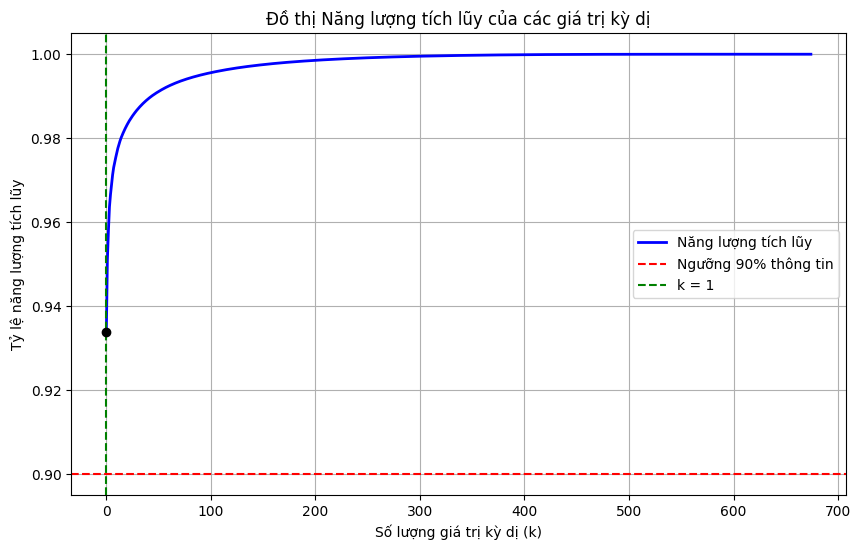

In [ ]:
M = np.array(Image.open("anh.jpg").convert("L"), dtype=float)
U, S, Vt = np.linalg.svd(M, full_matrices= False)

nangluong = S**2
nangluongtichluy = np.cumsum(nangluong) / np.sum(nangluong)
k_90 = np.argmax(nangluongtichluy >= 0.90) + 1

print(f"Tổng số giá trị kỳ dị tối đa: {len(S)}")
print(f"Giá trị k tối thiểu cần chọn để giữ lại >= 90% thông tin là: k = {k_90}")
print(f"Năng lượng tích lũy tại k = {k_90}: {nangluongtichluy[k_90 - 1]:.4f} ({nangluongtichluy[k_90 - 1]*100:.2f}%)")

plt.figure(figsize=(10, 6))
plt.plot(nangluongtichluy, color='blue', linewidth=2, label='Năng lượng tích lũy')
plt.axhline(y=0.90, color='red', linestyle='--', label='Ngưỡng 90% thông tin')
plt.axvline(x=k_90 - 1, color='green', linestyle='--', label=f'k = {k_90}')
plt.scatter(k_90 - 1, nangluongtichluy[k_90 - 1], color='black', zorder=5)

plt.title("Đồ thị Năng lượng tích lũy của các giá trị kỳ dị")
plt.xlabel("Số lượng giá trị kỳ dị (k)")
plt.ylabel("Tỷ lệ năng lượng tích lũy")
plt.legend()
plt.grid()
plt.show()